In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
import time
import mlflow


# Loading Data

In [3]:
df=pd.read_csv('data/cars.csv')

In [4]:

mappings = {'First Owner':1,
            'Second Owner':2,
            'Third Owner':3,
            'Fourth & Above Owner':4,
            'Test Drive Car':5}
df['owner']=df['owner'].map(mappings)
df['owner'].unique()

array([1, 2, 3, 4, 5])

In [5]:
df=df[(df['fuel']!='LPG') & (df['fuel']!='CNG')]
df['fuel'].unique()

array(['Diesel', 'Petrol'], dtype=object)

In [6]:
df['mileage']=df.mileage.str.split()
df['mileage']=df['mileage'].str[0].astype(float)

df['engine']=df.engine.str.split()
df['engine']=df['engine'].str[0].astype(float)

df['max_power']=df.max_power.str.split()
df['max_power']=df['max_power'].str[0].astype(float)

df['brand']=df.name.str.split()
df['brand']=df['brand'].str[0].astype(str)
                                    

df[['engine','mileage','max_power','brand']].head()

,engine,mileage,max_power,brand
0,1248.0,23.40,74.00,Maruti
1,1498.0,21.14,103.52,Skoda
2,1497.0,17.70,78.00,Honda
3,1396.0,23.00,90.00,Hyundai
4,1298.0,16.10,88.20,Maruti


In [7]:
df=df.drop(labels='torque',axis='columns')
df=df.drop(labels='name',axis='columns')
df=df[df['owner']!=5]

In [8]:

df.head()



,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0,Maruti
1,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0,Skoda
2,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0,Honda
3,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0,Hyundai
4,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0,Maruti


# Plotting

<Axes: xlabel='owner', ylabel='count'>

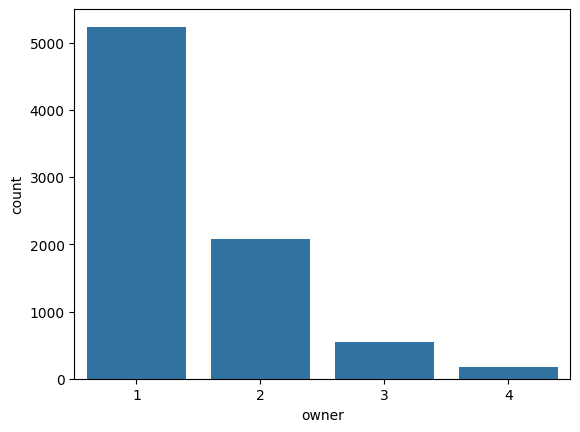

In [9]:
sns.countplot(data=df,x='owner')

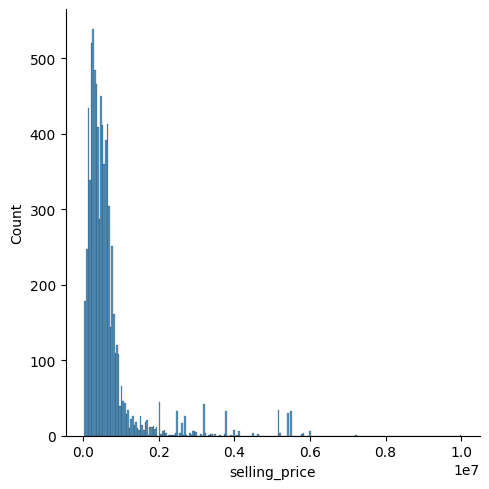

In [10]:
sns.displot(data=df,x='selling_price')

<Axes: xlabel='owner', ylabel='selling_price'>

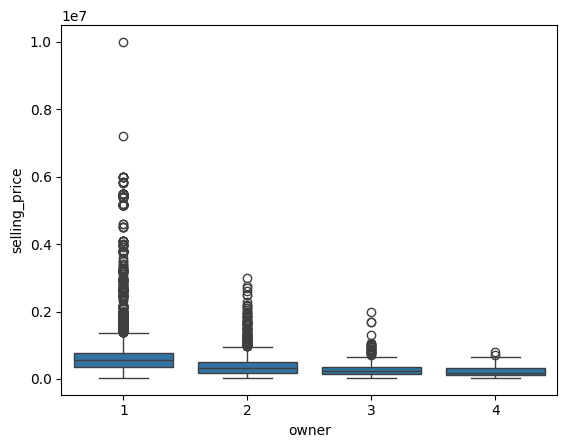

In [11]:
sns.boxplot(data=df,x='owner',y='selling_price')

<Axes: xlabel='year', ylabel='selling_price'>

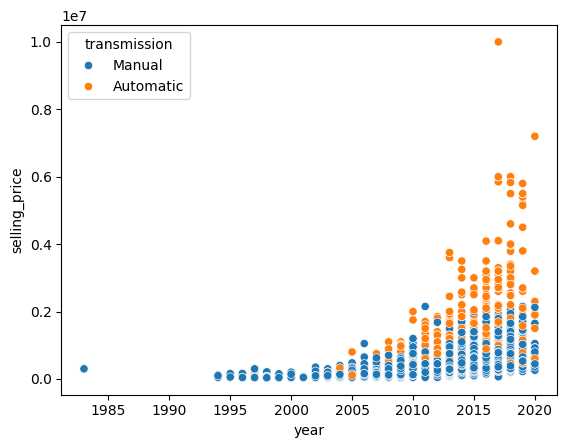

In [12]:
sns.scatterplot(data=df,x='year',y='selling_price',hue='transmission')

<Axes: xlabel='max_power', ylabel='selling_price'>

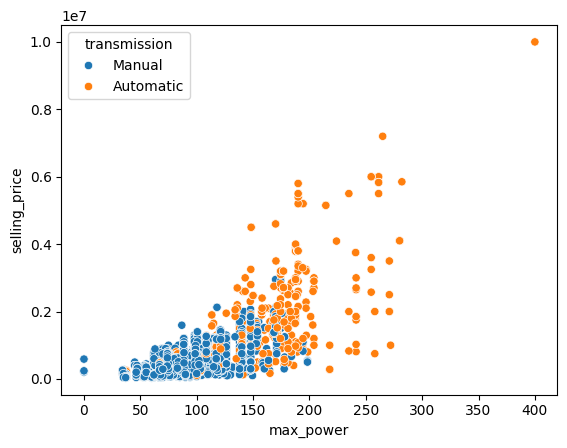

In [13]:
sns.scatterplot(data=df,x='max_power',y='selling_price',hue='transmission')

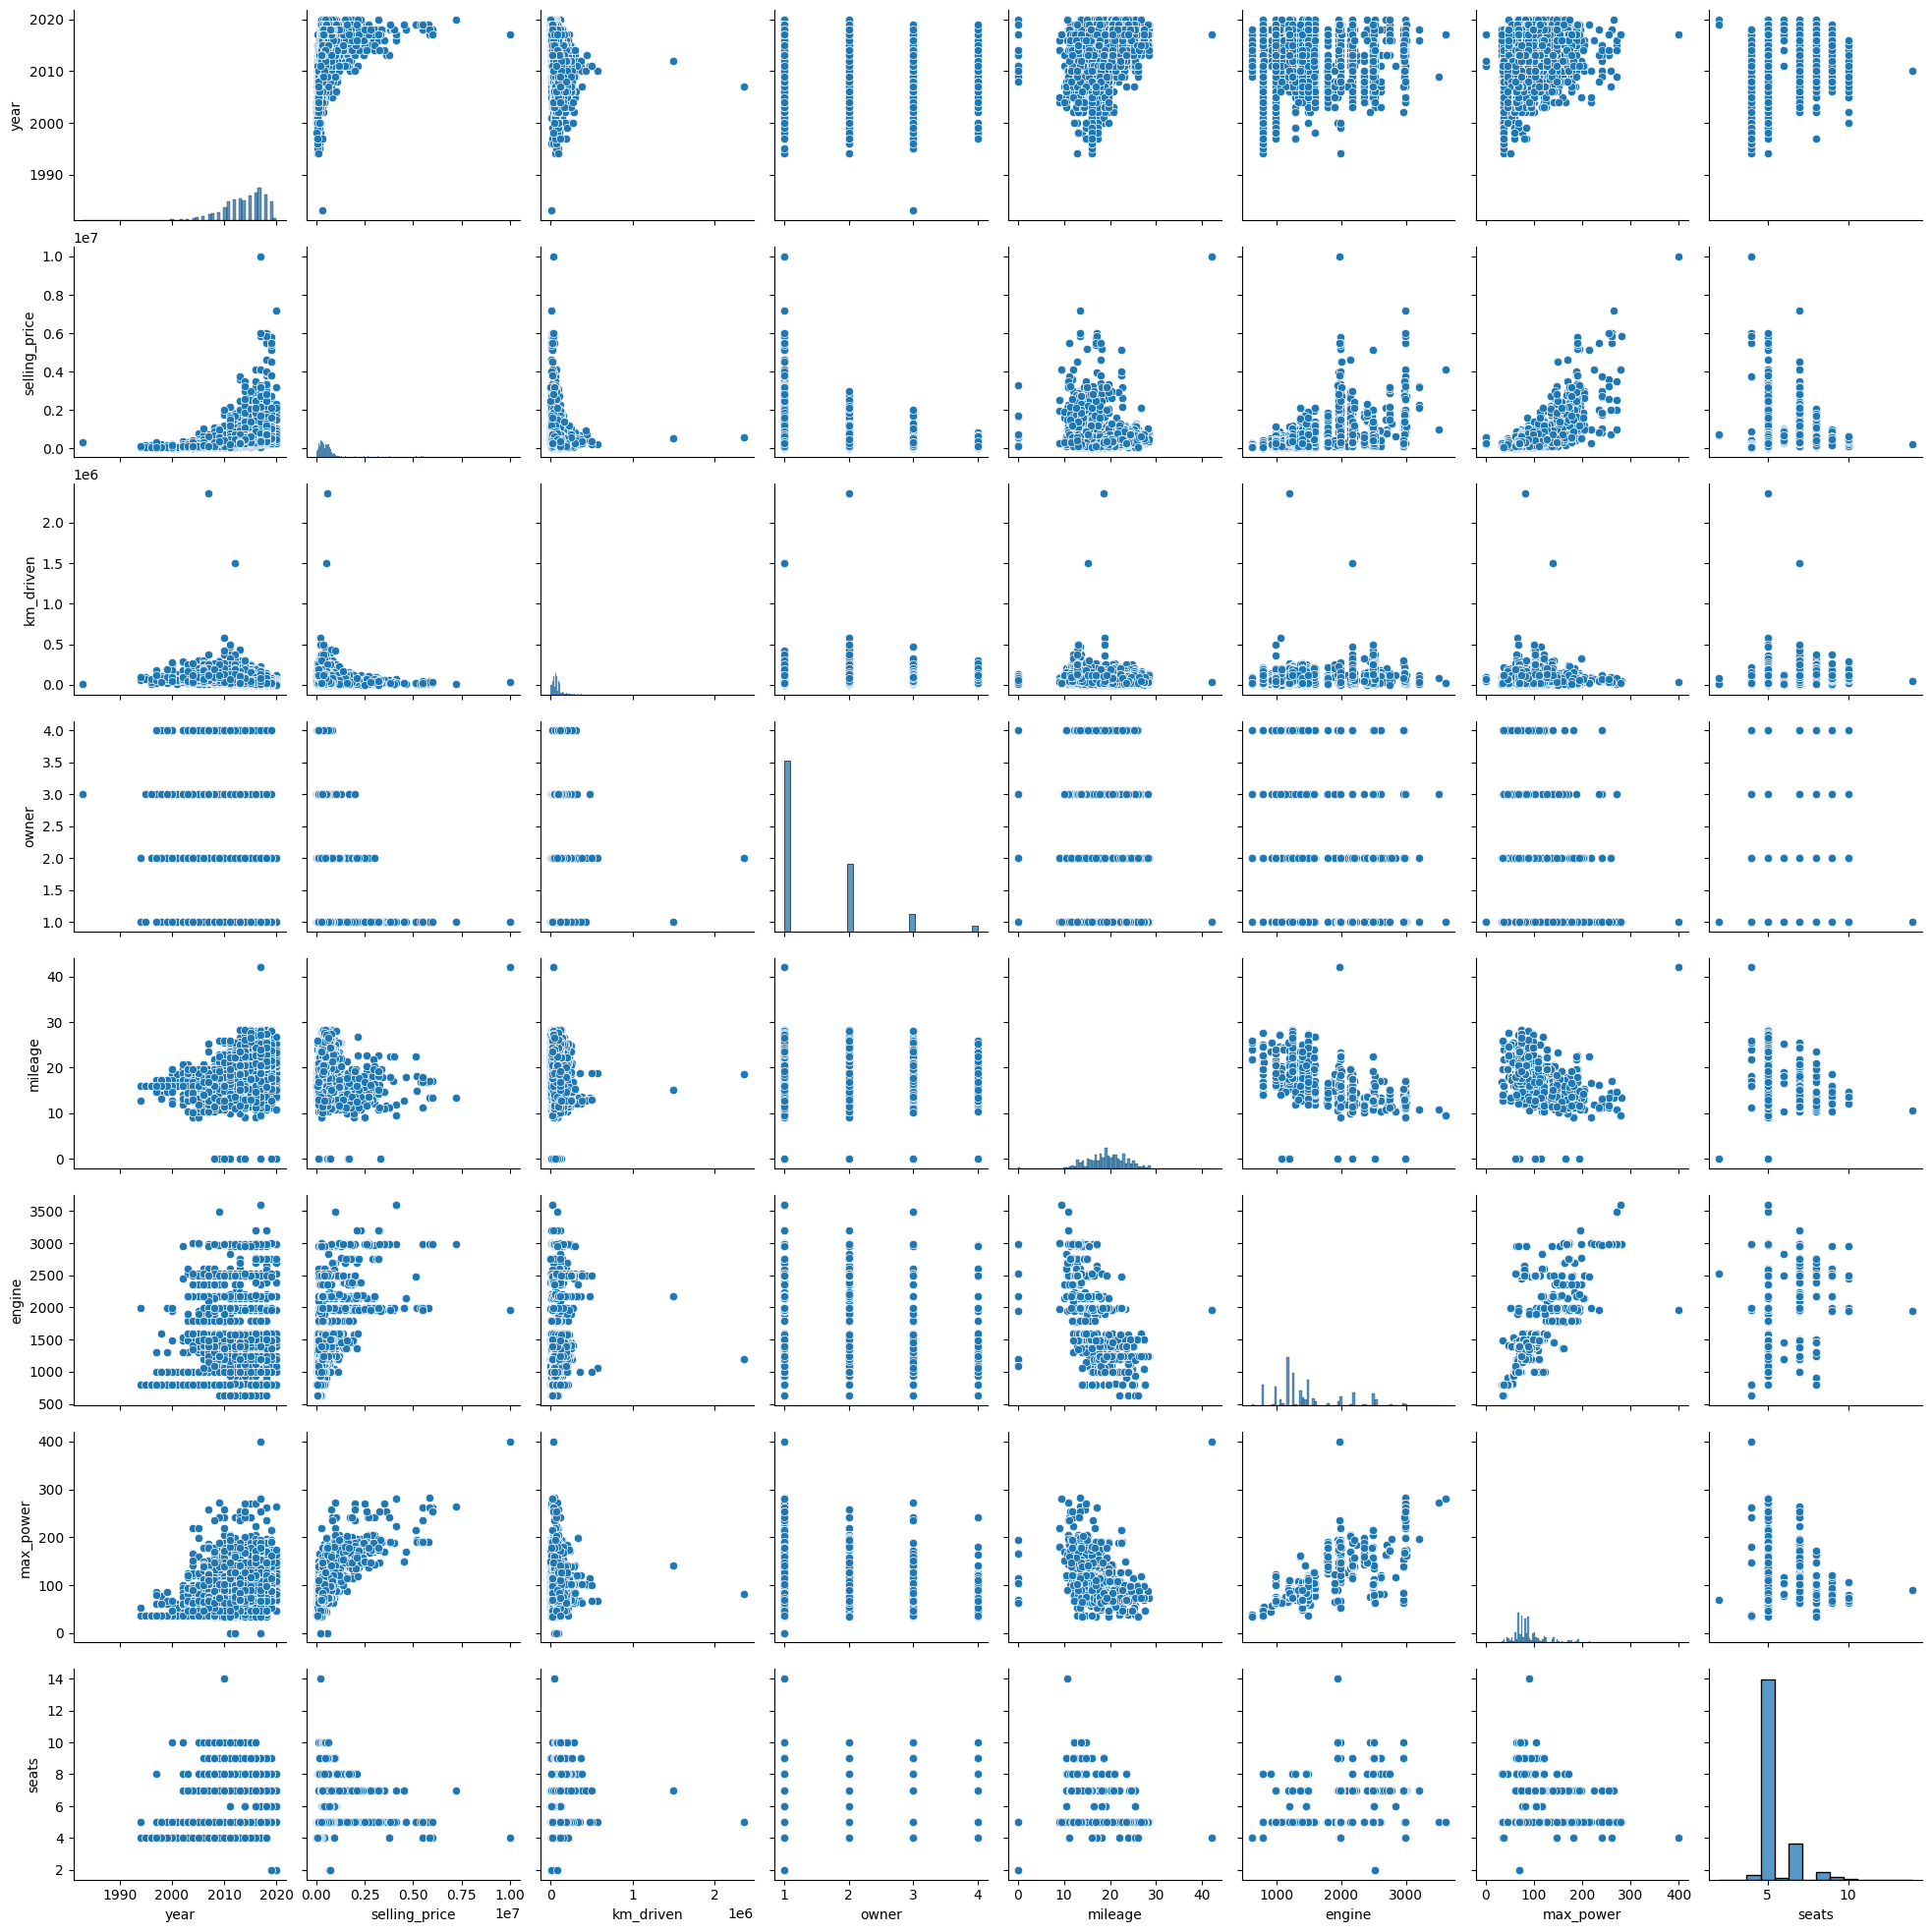

In [14]:
sns.pairplot(df)

# One Hot Encoding

In [15]:
categorical_columns = ['brand','fuel']

for col in categorical_columns:
    
    print(f"Category in {col} is : {df[col].unique()}")

Category in brand is : ['Maruti' 'Skoda' 'Honda' 'Hyundai' 'Toyota' 'Ford' 'Renault' 'Mahindra'
 'Tata' 'Chevrolet' 'Fiat' 'Datsun' 'Jeep' 'Mercedes-Benz' 'Mitsubishi'
 'Audi' 'Volkswagen' 'BMW' 'Nissan' 'Lexus' 'Jaguar' 'Land' 'MG' 'Volvo'
 'Daewoo' 'Kia' 'Force' 'Ambassador' 'Ashok' 'Isuzu' 'Opel' 'Peugeot']
Category in fuel is : ['Diesel' 'Petrol']


In [54]:
from sklearn.preprocessing import LabelEncoder

label_encoder_fuel = LabelEncoder()
label_encoder_transmission = LabelEncoder()
label_encoder_seller_type = LabelEncoder()
label_encoder_brand=LabelEncoder()

df['fuel'] = label_encoder_fuel.fit_transform(df['fuel'])
df['transmission'] = label_encoder_transmission.fit_transform(df['transmission'])
df['seller_type'] = label_encoder_seller_type.fit_transform(df['seller_type'])
df['brand'] = label_encoder_brand.fit_transform(df['brand'])


<Axes: >

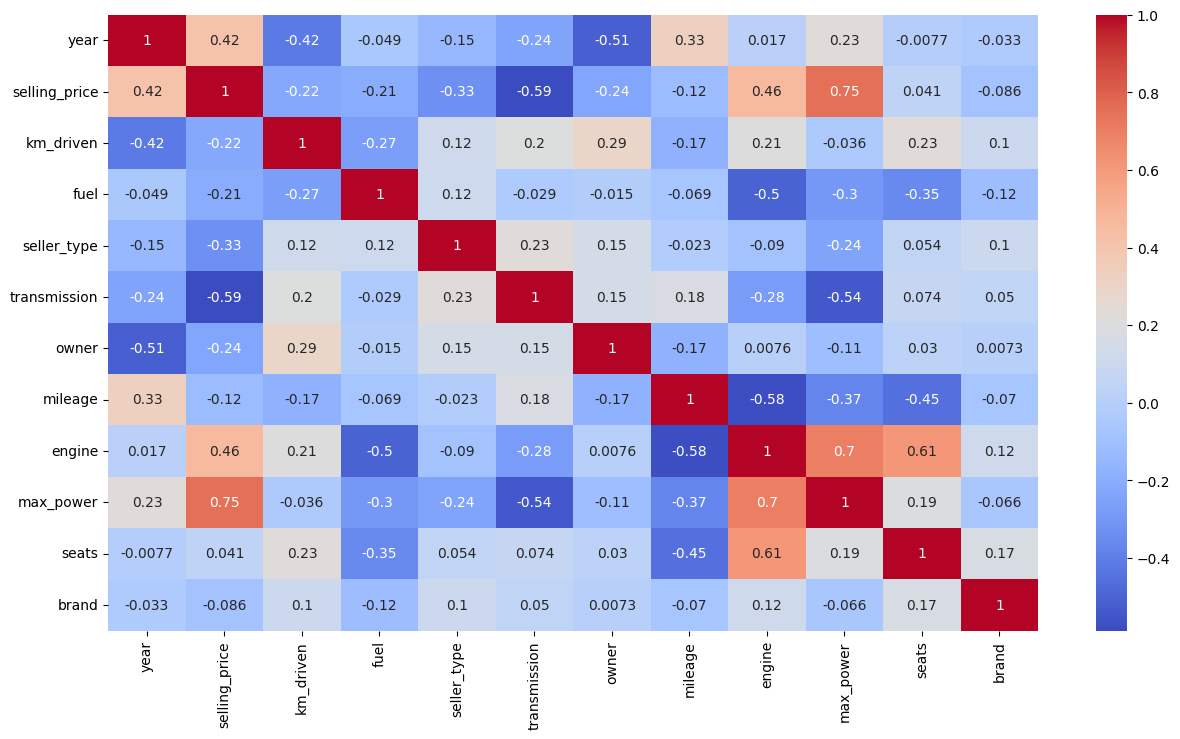

In [55]:
plt.figure(figsize = (15,8))
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap="coolwarm")

# Boxplot visualize outliers

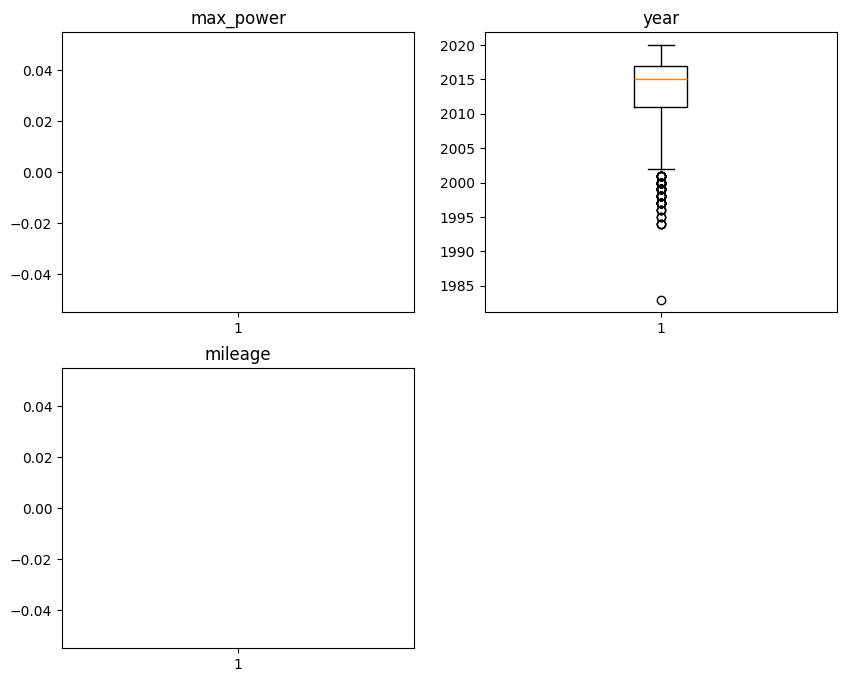

In [56]:
col_dict = {'max_power':1, 'year':2,'mileage':3}
plt.figure(figsize=(10,8))
for var, i in col_dict.items():
    plt.subplot(2,2,i)
    plt.boxplot(df[var])
    plt.title(var)
plt.show()

In [57]:
def outlier_count(col, data = X_train):
    if not np.issubdtype(data[col].dtype, np.number):
        return
    
    # calculate your 25% quatile and 75% quatile
    q75, q25 = np.percentile(data[col], [75, 25])
    
    # calculate your inter quatile
    iqr = q75 - q25
    
    # min_val and max_val
    min_val = q25 - (iqr*1.5)
    max_val = q75 + (iqr*1.5)
    
    # count number of outliers, which are the data that are less than min_val or more than max_val calculated above
    outlier_count = len(np.where((data[col] > max_val) | (data[col] < min_val))[0])
    
    # calculate the percentage of the outliers
    outlier_percent = round(outlier_count/len(data[col])*100, 2)
    
    if(outlier_count > 0):
        print("\n"+15*'-' + col + 15*'-'+"\n")
        print('Number of outliers: {}'.format(outlier_count))
        print('Percent of data that is outlier: {}%'.format(outlier_percent))

In [58]:
df1=df[df['year']<1993]
df1

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
316,1983,300000,10000,0,1,1,3,NaN,NaN,NaN,NaN,19


In [59]:
y_train

array([0, 0, 0, ..., 3, 3, 3])

# Analyze Y label to categories

observe the class imbalance

[7732  182  113    1]
[   29999.    2522499.25  5014999.5   7507499.75 10000000.  ]


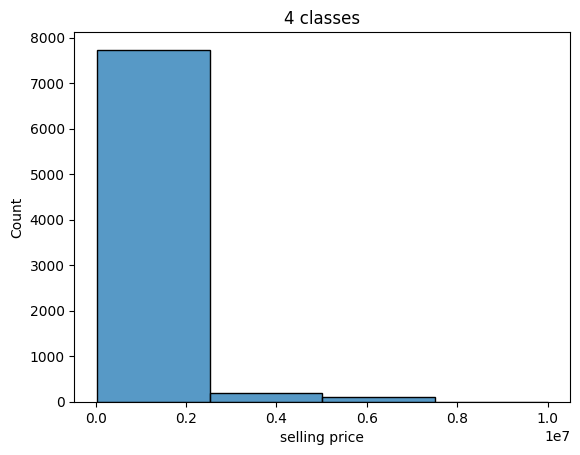

In [60]:
sns.histplot(df['selling_price'],bins=4,)
plt.title('4 classes')
plt.xlabel('selling price')
a,b=np.histogram(df['selling_price'],bins=4)
print(a)
price=np.round(b,2)
print(price)

In [61]:
a=pd.cut(df['selling_price'],bins=4,labels=['30K-130K','130K-550K','550K-2.35M','2.35M-10M'])
a.value_counts()

selling_price
30K-130K      7732
130K-550K      182
550K-2.35M     113
2.35M-10M        1
Name: count, dtype: int64

In [62]:
df['selling_price'].describe()

count    8.028000e+03
mean     6.403937e+05
std      8.027015e+05
min      2.999900e+04
25%      2.600000e+05
50%      4.500000e+05
75%      6.800000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

Trying to balance classes to use IQR range fro binning

#### '30K-260K':0
#### '260K-450K':1
#### '450K-680K':2
#### '680K-10M':3

change our df before splitting

# Feature Selection Splitting Test and Train set

### Split into the bins our selling price

In [63]:
condition=[(df['selling_price']>30000) & (df['selling_price']<260000),
           (df['selling_price']>260000) & (df['selling_price']<450000),
           (df['selling_price']>450000) & (df['selling_price']<680000),
           (df['selling_price']>680000) & (df['selling_price']<10000000)]
choices=[0,1,2,3]
#lebels=['30K-260K','260K-450K','450K-680K','680K-10M']
y=np.select(choicelist=choices,condlist=condition)

In [64]:
np.unique(y)

array([0, 1, 2, 3])

In [65]:
numeric_features = ['year', 'max_power', 'mileage',]
categorical_features = ['brand', 'fuel',]
X=df[numeric_features + categorical_features]
print(X.shape) 
print(y.shape)
print(type(X))
print(type(y))

(8028, 5)
(8028,)
<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>


In [66]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [67]:
type(y_train)

numpy.ndarray

In [68]:
X_train.shape, X_test.shape

((6422, 5), (1606, 5))

In [69]:
y_train.shape, y_test.shape

((6422,), (1606,))

In [70]:
y_test

array([0, 3, 1, ..., 0, 3, 1])

# Preprocessing on X train X test

In [71]:
print('X_train_missing_values:')
print(X_train.isnull().sum())
print('\nX_test_missing_values:')
print(X_test.isnull().sum())
print('\ny_train_missing_values:')


X_train_missing_values:
year           0
max_power    165
mileage      171
brand          0
fuel           0
dtype: int64

X_test_missing_values:
year          0
max_power    43
mileage      43
brand         0
fuel          0
dtype: int64

y_train_missing_values:


<Axes: xlabel='max_power', ylabel='Count'>

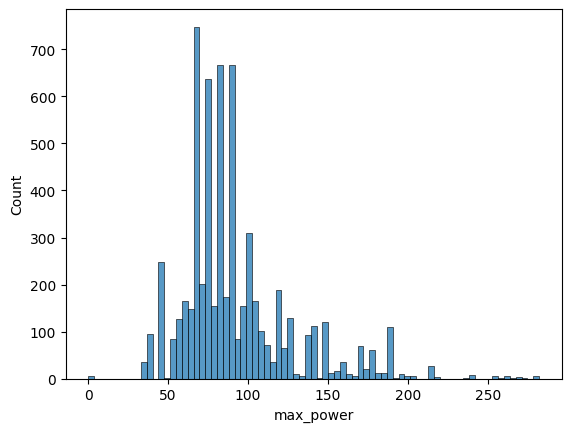

In [72]:
sns.histplot(data=X_train,x=X_train['max_power'])

Filling Missing Values

In [73]:
X_train['max_power']=np.nan_to_num(X_train['max_power'],nan=X_train['max_power'].median())
X_test['max_power']=np.nan_to_num(X_test['max_power'],nan=X_train['max_power'].median())
X_train['mileage']=np.nan_to_num(X_train['mileage'],nan=X_train['mileage'].median())
X_test['mileage']=np.nan_to_num(X_test['mileage'],nan=X_train['mileage'].median())


In [74]:
print("X_train_set missing_values: ")
print(X_train.isnull().sum())
print('\nX_test_set missing_values:')
print(X_test.isnull().sum())

X_train_set missing_values: 
year         0
max_power    0
mileage      0
brand        0
fuel         0
dtype: int64

X_test_set missing_values:
year         0
max_power    0
mileage      0
brand        0
fuel         0
dtype: int64


In [75]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train.shape


(6422, 5)

In [76]:
# add intercept to our X
intercept = np.ones((X_train.shape[0], 1))
X_train   = np.concatenate((intercept, X_train), axis=1)  #add intercept
intercept = np.ones((X_test.shape[0], 1))
X_test    = np.concatenate((intercept, X_test), axis=1)

In [77]:
k = 4  # no. of class  (can also use np.unique)
m = X_train.shape[0]  # no.of samples
n = X_train.shape[1]  # no. of features
Y_train_encoded = np.zeros((m, k))
for each_class in range(k):
    cond = y_train==each_class
    Y_train_encoded[np.where(cond), each_class] = 1
Y_test_encoded = np.zeros((m, k))
for each_class in range(k):
    cond = y_test==each_class
    Y_test_encoded[np.where(cond), each_class] = 1
Y_test_encoded
print(m,n,k)

6422 6 4


# Modeling Classification Metrics and Ridge regression

In [78]:
class LogisticRegression:
    
    def __init__(self, k, n, method, alpha = 0.001, max_iter=5000,l=0.1,use_penalty=bool):
        self.k = k
        self.n = n
        self.alpha = alpha
        self.max_iter = max_iter
        self.method = method
        self.l=l
        self.use_penalty=use_penalty
    
    def fit(self, X, Y):
        self.W = np.random.rand(self.n, self.k)
        self.losses = []
        
        if self.method == "batch":
            start_time = time.time()
            for i in range(self.max_iter):
                loss, grad =  self.gradient(X, Y)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                if i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            print(f"time taken: {time.time() - start_time}")
            
        elif self.method == "minibatch":
            start_time = time.time()
            batch_size = int(0.3 * X.shape[0])
            for i in range(self.max_iter):
                ix = np.random.randint(0, X.shape[0]) #<----with replacement
                batch_X = X[ix:ix+batch_size]
                batch_Y = Y[ix:ix+batch_size]
                loss, grad = self.gradient(batch_X, batch_Y)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                if i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            print(f"time taken: {time.time() - start_time}")
            
        elif self.method == "sto":
            start_time = time.time()
            list_of_used_ix = []
            for i in range(self.max_iter):
                idx = np.random.randint(X.shape[0])
                while i in list_of_used_ix:
                    idx = np.random.randint(X.shape[0])
                X_train = X[idx, :].reshape(1, -1)
                Y_train = Y[idx]
                loss, grad = self.gradient(X_train, Y_train)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                
                list_of_used_ix.append(i)
                if len(list_of_used_ix) == X.shape[0]:
                    list_of_used_ix = []
                if i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            print(f"time taken: {time.time() - start_time}")
            
        else:
            raise ValueError('Method must be one of the followings: "batch", "minibatch" or "sto".')
        
        
    def gradient(self, X, Y): #-------------------Add penatlry(Ridge Regression) to gradient value
        m = X.shape[0]
        h = self.h_theta(X, self.W)
        loss = - np.sum(Y*np.log(h)) / m
        error = h - Y
        grad = self.softmax_grad(X, error)
        if self.use_penalty:
            W_reg=self.W.copy()
            loss = loss+ (self.l / (2.0 * m)) * np.sum(W_reg ** 2)  #--------- Penalty  
            grad = grad+(self.l / m) * W_reg                           
        return loss, grad

    def softmax(self, theta_t_x):
        return np.exp(theta_t_x) / np.sum(np.exp(theta_t_x), axis=1, keepdims=True)

    def softmax_grad(self, X, error):  
        return  X.T @ error 

    def h_theta(self, X, W):
        '''
        Input:
            X shape: (m, n)
            w shape: (n, k)
        Returns:
            yhat shape: (m, k)
        '''
        return self.softmax(X @ W)
    
    def predict(self, X_test):
        return np.argmax(self.h_theta(X_test, self.W), axis=1)
    
    def plot(self):
        plt.plot(np.arange(len(self.losses)) , self.losses, label = "Train Losses")
        plt.title("Losses")
        plt.xlabel("epoch")
        plt.ylabel("losses")
        plt.legend()
    def accuracy(self,y_pred,y_test):
        self.y_pred=y_pred
        self.y_test=y_test
        correct=0
        F=0
        for i in y_pred==y_test:
            if i==True:
                correct=correct+1
            else:
                F=F+1
        total=correct/(correct+F)
        print(f'Accuracy: {round(total,2)}')
        mlflow.log_metric("Accuracy", total)
        # Initialize weights of each classe 
        wclasse=[]
        self.wclasse=wclasse
        classes,count=np.unique(y_test,return_counts=True)
        for i in range(k):
            i=count[i]/sum(count)
            wclasse.append(i)

    def precision(self):
        Y_test_encoded = np.zeros((m, k))
        for each_class in range(k):
            cond = self.y_test==each_class
            Y_test_encoded[np.where(cond), each_class] = 1
        Y_pred_encoded = np.zeros((m, k))
        for each_class in range(k):
            cond = self.y_pred==each_class
            Y_pred_encoded[np.where(cond), each_class] = 1
        self.Y_pred_encoded=Y_pred_encoded
        self.Y_test_encoded=Y_test_encoded
        TP=[]
        FP=[]
        TN=[]
        FN=[]
        self.TP=TP
        self.FP=FP
        self.TN=TN
        self.FN=FN
        Tprecision=[]
        self.Tprecision=Tprecision
        for i in range(k):
            TP1=(Y_pred_encoded[:,i]==1) & (Y_test_encoded[:,i]==1) 
            TP.append(np.size(TP1[TP1]))
            FP1=(Y_pred_encoded[:,i]==1) & (Y_test_encoded[:,i]==0)
            FP.append(np.size(FP1[FP1]))
            TN1=(Y_pred_encoded[:,i]==0) & (Y_test_encoded[:,i]==0)
            TN.append(np.size(TN1[TN1]))
            FN1=(Y_pred_encoded[:,i]==0) & (Y_test_encoded[:,i]==1)
            FN.append(np.size(FN1[FN1]))
        for i in range(k):
            Tprecision1=TP[i]/(TP[i]+FP[i])
            Tprecision.append(Tprecision1)
            print(f'Precision for {i} class: {Tprecision1:.2f}.')
        return Tprecision
    def recall(self):
        Trecall=[]
        self.Trecall=Trecall
        for i in range(k):
            Trecall1=self.TP[i]/(self.TP[i]+self.FN[i])
            Trecall.append(Trecall1)
            print(f'Recall for {i} class: {Trecall1:.2f}.')
        return Trecall
    def f1score(self):
        Tf1score=[]
        self.Tf1score=Tf1score
        for i in range(k):
            Tf1score1=(2*self.Tprecision[i]*self.Trecall[i])/(self.Trecall[i]+self.Tprecision[i])
            Tf1score.append(Tf1score1)
            print(f'F1 score for {i} class: {Tf1score1:.2f}.')
            
    def macroprecision(self):
        Tmacroprecision=sum(self.Tprecision)/k
        self.Tmacroprecision=Tmacroprecision
        print(f'Macro precision: {Tmacroprecision:.2f}')
        mlflow.log_metric("Macroprecision", Tmacroprecision)
        return Tmacroprecision
    def macrorecall(self):
        Tmacrorecall=sum(self.Trecall)/k
        self.Tmacrorecall=Tmacrorecall
        print(f'Macro precision: {Tmacrorecall:.2f}')
        mlflow.log_metric("Macrorecall", Tmacrorecall)
        return Tmacrorecall
    def macrof1(self):
        Tmacrof1=sum(self.Tf1score)/k
        self.Tmacrof1=Tmacrof1
        print(f'Macro f1 score: {Tmacrof1:.2f}')
        mlflow.log_metric("Macrof1", Tmacrof1)
        return Tmacrof1
    
    def wprecision(self):
        wprecision=np.array(self.Tprecision).T@np.array(self.wclasse)
        print(f'Weighted precision: {wprecision:.2f}')
        mlflow.log_metric("Weighted precision", wprecision)
            
    def wrecall(self):
        wprecall=np.array(self.Trecall).T@np.array(self.wclasse)
        print(f'Weighted recall: {wprecall:.2f}')
        mlflow.log_metric("Weighted recall", wprecall)
    def wf1(self):
        wf1=np.array(self.Tf1score).T@np.array(self.wclasse)
        print(f'Weighted f1: {wf1:.2f}')
        mlflow.log_metric("Weighted f1", wf1)
        

In [79]:
model=LogisticRegression(k,X_train.shape[1],method='minibatch',use_penalty=True)
model.fit(X_train,Y_train_encoded)
y_pred=model.predict(X_test)

Loss at iteration 0 1.6960155699564337
Loss at iteration 500 0.7523678041445497
Loss at iteration 1000 0.7691014478530308
Loss at iteration 1500 0.7673468599148119
Loss at iteration 2000 0.803292488217918
Loss at iteration 2500 0.7582290971722617
Loss at iteration 3000 0.7589506470153626
Loss at iteration 3500 0.7940084032156693
Loss at iteration 4000 0.7525402334641585
Loss at iteration 4500 0.7133383827368169
time taken: 0.6578421592712402


In [82]:
model.accuracy(y_pred,y_test)
model.precision()
model.recall()
model.f1score()
model.macrof1()
model.macroprecision()
model.macrorecall()
model.wprecision()
model.wrecall()
model.wf1()

Accuracy: 0.67
Precision for 0 class: 0.78.
Precision for 1 class: 0.60.
Precision for 2 class: 0.47.
Precision for 3 class: 0.81.
Recall for 0 class: 0.76.
Recall for 1 class: 0.52.
Recall for 2 class: 0.60.
Recall for 3 class: 0.76.
F1 score for 0 class: 0.77.
F1 score for 1 class: 0.56.
F1 score for 2 class: 0.53.
F1 score for 3 class: 0.78.
Macro f1 score: 0.66
Macro precision: 0.67
Macro precision: 0.66
Weighted precision: 0.68
Weighted recall: 0.67
Weighted f1: 0.67


In [83]:
from sklearn.metrics import classification_report
print("Report: ", classification_report(y_test, y_pred))

Report:                precision    recall  f1-score   support

           0       0.78      0.76      0.77       470
           1       0.60      0.52      0.56       406
           2       0.47      0.60      0.53       344
           3       0.81      0.76      0.78       386

    accuracy                           0.67      1606
   macro avg       0.67      0.66      0.66      1606
weighted avg       0.68      0.67      0.67      1606



Support show us the number of classes out of 1606 0 class has 470 sample Overall our classes are balanced consequently I will can use not weighted metrics to compare my model

# Deployment 

In [81]:
import os
import mlflow
os.environ["MLFLOW_TRACKING_URI"] = "https://mlflow.ml.brain.cs.ait.ac.th"
os.environ["MLFLOW_TRACKING_USERNAME"] = "admin"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "password"
mlflow.set_experiment("A3_st125983")

<Experiment: artifact_location='mlflow-artifacts:/633675445197669206', creation_time=1759657549595, experiment_id='633675445197669206', last_update_time=1759657549595, lifecycle_stage='active', name='A3_st125983', tags={}>

We loops through each dictionary in param_set and name it unique

In [ ]:
mlflow.end_run() #Mae sure we end any active run before staring a new one
param_sets = [
    {"method": "batch", "use_penalty": True, "alpha": 0.001},
    {"method": "batch", "use_penalty": False, "alpha": 0.001},
    {"method": "batch", "use_penalty": True, "alpha": 0.0001},
    {"method": "batch", "use_penalty": False, "alpha": 0.0001},
    {"method": "minibatch", "use_penalty": True, "alpha": 0.001},
    {"method": "minibatch", "use_penalty": False, "alpha": 0.001},
    {"method": "minibatch", "use_penalty": True, "alpha": 0.0001},
    {"method": "minibatch", "use_penalty": False, "alpha": 0.0001},
    {"method": "sto", "use_penalty": True, "alpha": 0.001},
    {"method": "sto", "use_penalty": False, "alpha": 0.001},
    {"method": "sto", "use_penalty": True, "alpha": 0.0001},
    {"method": "sto", "use_penalty": False, "alpha": 0.0001}
]

# Start the main parent run
for params in param_sets:
    run_name = f"method_{params['method']}_penalty_{params['use_penalty']}"
    with mlflow.start_run(run_name=run_name, nested=True):
        mlflow.log_params(params)
        model = LogisticRegression(k,X_train.shape[1],**params)  
        model.fit(X_train, Y_train_encoded)
        y_pred = model.predict(X_test)
        model.accuracy(y_pred, y_test)
        model.precision()
        model.recall()
        model.f1score()
        model.macrof1()
        model.macroprecision()
        model.macrorecall()
        model.wprecision()
        model.wrecall()
        model.wf1()
    mlflow.end_run()


*![image.png](mlflow2.png)*
### I choose mini batch with learning rate 0.001 as it perform better than full bach as I didnt touch max_iter=500 our model was not able to find global minima in 500 iterations therefore perform worse

In [ ]:
experiment_id = "633675445197669206"

best_run = mlflow.search_runs(
    experiment_ids=[experiment_id],
    order_by=["metrics.Macrof1 DESC"], # Note: Check the exact metric name in your UI
    max_results=1
).iloc[0]

best_run_id = best_run.run_id
print(f"Best run ID: {best_run_id}")
print(f"Best Macro F1 Score: {best_run['metrics.Macrof1']:.4f}")

In [85]:
model = LogisticRegression(k,X_train.shape[1],method='minibatch',use_penalty=False,alpha=0.001)
model.fit(X_train,Y_train_encoded)
signature = mlflow.models.infer_signature(X_train, model.predict(X_train))
mlflow.sklearn.log_model(
sk_model=model,
artifact_path="model",
signature=signature,
registered_model_name='A3_Car_st125983'
    )

Loss at iteration 0 1.535722299790399
Loss at iteration 500 0.7499567669121378
Loss at iteration 1000 0.7628503048572035
Loss at iteration 1500 0.7644655479416385
Loss at iteration 2000 0.7332766927809778
Loss at iteration 2500 0.7649701440898066
Loss at iteration 3000 0.7621809103329601


2025/10/05 22:29:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Loss at iteration 3500 0.7534865893339542
Loss at iteration 4000 0.7276660365106933
Loss at iteration 4500 0.7551754023782129
time taken: 0.6524479389190674


Successfully registered model 'A3_Car_st125983'.
2025/10/05 22:29:24 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: A3_Car_st125983, version 1
Created version '1' of model 'A3_Car_st125983'.


# Inference

In [90]:
import joblib

joblib.dump(model,"models/logistic_model.joblib")

['models/logistic_model.joblib']

In [91]:
import joblib
best_model=joblib.load("models/logistic_model.joblib")

In [92]:
df[['year','max_power','selling_price','fuel','brand','mileage']].loc[1]

year               2014.00
max_power           103.52
selling_price    370000.00
fuel                  0.00
brand                27.00
mileage              21.14
Name: 1, dtype: float64

In [93]:
sample_data = [[2014, 103.52, 0 ,27, 21.14,]]

column_names = ['year', 'max_power', 'fuel','brand', 'mileage']

sample_df = pd.DataFrame(sample_data, columns=column_names)
sample_df


,year,max_power,fuel,brand,mileage
0,2014,103.52,0,27,21.14


In [94]:
sample_array = sample_df.to_numpy()
#add intercept
sample_with_bias = np.insert(sample_array, 0, 1, axis=1)
prediction = best_model.predict(sample_with_bias)
prediction

/var/folders/k1/5yp6fwzs6810rxp0qptj32bm0000gq/T/ipykernel_17099/3922815708.py:77: RuntimeWarning: overflow encountered in exp
  return np.exp(theta_t_x) / np.sum(np.exp(theta_t_x), axis=1, keepdims=True)
/var/folders/k1/5yp6fwzs6810rxp0qptj32bm0000gq/T/ipykernel_17099/3922815708.py:77: RuntimeWarning: invalid value encountered in divide
  return np.exp(theta_t_x) / np.sum(np.exp(theta_t_x), axis=1, keepdims=True)


array([2])

### as we bin early our y to 100K-550K as bin 2